
# Lithium atomic beam: transverse cooling + optional 2D MOT + downstream orifice optimization

This notebook adds:

**(i)** Side-view schematic plots (x vs z) with representative trajectories for three cases:
1. No cooling, no 2D MOT
2. Transverse cooling in mirror region only
3. Transverse cooling + optimized 2D MOT just behind the mirrors

**(ii)** Prints the **optimized 2D MOT parameters** (length + spring/damping) and the achieved gain in flux through the downstream orifice.

## Notes
- Physics is a **fast design-level model** (two-level Doppler molasses in the mirror region, and a linear spring+damping model for the 2D MOT).
- The 2D MOT model captures the “focusing + damping” effect:
  \[ \mathbf F_\perp = -\kappa \mathbf r_\perp - \beta \mathbf v_\perp. \]
- The downstream orifice is a **1 cm diameter** aperture located **50 cm after the mirror end**, as requested.

- Updated propagation now uses each atom's own longitudinal velocity through the mirror and 2D-MOT regions, fixes the downstream drift geometry, and records several intermediate trajectory points so the side-view is more physical.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(12345)

# ---------------- Physical constants ----------------
h = 6.62607015e-34
hbar = h/(2*np.pi)
kB = 1.380649e-23
amu = 1.66053906660e-27

print("Imports and constants loaded.")

Imports and constants loaded.



## User parameters (edit here)


In [4]:
# ---------------- Isotope ----------------
isotope = "Li-6"   # "Li-6" or "Li-7"
mass = {"Li-6": 6.015*amu, "Li-7": 7.016*amu}[isotope]

# ---------------- Li D2 (approx) ----------------
lambda0 = {"Li-6": 670.977e-9, "Li-7": 670.962e-9}[isotope] # transition wavelength
k = 2*np.pi/lambda0 # wavevector, used to calculate recoil velocity and Doppler shift
Gamma = 2*np.pi*5.87e6   # natural linewidth in Hz (rad/s)
Isat_mW_cm2 = 2.54       # saturation intensity in mW/cm^2, two-level approx, excitations are just as fast as decays
Isat = Isat_mW_cm2 * 1e-3 / 1e-4  # saturation intensity in W/m^2

# ---------------- Oven/source ----------------
T_oven_C = 800.0
T_oven_K = T_oven_C + 273.15
hole_d_mm = 0.3

# ---------------- Geometry ----------------
z_start_cm = 10.0     # mirror start plane measured from hole
L_cool_cm  = 20.0     # mirror region length
z_after_cm = 50.0     # distance after mirror end to orifice plane
orifice_diam_cm = 1.0

# Optional skimmer at z_start
use_skimmer = True
skimmer_diam_cm = 1.0

# ---------------- Mirrors / laser knobs ----------------
N_bounce_x = 6 # number of bounces in x (horizontal) direction
N_bounce_y = 6 # number of bounces in y (vertical) direction
Rpass_y = 0.90 # reflectivity for p-polarized light
Rpass_x = 0.90 # reflectivity for p-polarized light

Px_mW = 80.0
Py_mW = 80.0
w_mm  = 6.0

delta_over_Gamma = -1.0   # detuning in units of Gamma (negative for red detuning)

# ---------------- MC + time step ----------------
dt = 2e-6
include_diffusion = True
alpha_diff = 0.5

print(f"Isotope={isotope}, T_oven={T_oven_C:.0f} C, delta/Gamma={delta_over_Gamma:.2f}")


Isotope=Li-6, T_oven=800 C, delta/Gamma=-1.00



## Effusive flux estimate (order-of-magnitude)


In [ ]:
# NIST Antoine-like fit (order-of-mag)
ANTOINE_A = 4.98831
ANTOINE_B = 7918.984
ANTOINE_C = -9.52

# Standard vapor pressure formular (Antoine equation) for lithium, returns in Pa
def lithium_vapor_pressure_Pa(T_K):
    log10P_bar = ANTOINE_A - (ANTOINE_B / (T_K + ANTOINE_C))
    return (10**log10P_bar) * 1e5

# Mean speed from Maxwell-Boltzmann distribution
def mean_speed_MB(T_K, m):
    return np.sqrt(8*kB*T_K/(np.pi*m))

# Effusive flux through a hole, in atoms/s, given T, m, and hole diameter in mm
''' Note: Steffens et al. (1977) used a flux of 2e+14 atoms/s '''
def effusive_flux_atoms_per_s(T_K, m, hole_d_mm):
    P = lithium_vapor_pressure_Pa(T_K)
    n = P/(kB*T_K)
    vbar = mean_speed_MB(T_K, m)
    A = np.pi*(hole_d_mm*1e-3/2)**2
    return 0.25*n*vbar*A, P, n, vbar, A

Ndot_hole, P_oven, n_oven, vbar, A_hole = effusive_flux_atoms_per_s(T_oven_K, mass, hole_d_mm)
print(f"Vapor pressure ~ {P_oven:.3g} Pa, mean speed ~ {vbar:.1f} m/s")
print(f"Effusive flux out of {hole_d_mm:.1f} mm hole: Ndot_hole ~ {Ndot_hole:.3e} atoms/s")


2.3568020689371766e+22
Vapor pressure ~ 349 Pa, mean speed ~ 1943.6 m/s
Effusive flux out of 0.3 mm hole: Ndot_hole ~ 8.095e+17 atoms/s



## Mirror-pass gain and Doppler molasses model


In [11]:
# After each reflection, beam intensity is reduced, so total beam intensity is sum of geometric series:
def gain_geometric(N, R):
    if abs(1-R) < 1e-12:
        return float(N)
    return (1 - R**N)/(1 - R)

# Standard function for intensity of a Gaussain beam, given Power and waist
def gaussian_I0(P_W, w_m):
    return 2*P_W/(np.pi*w_m*w_m)

# Scattering rate for a given effective detuning (delta_eff), saturation parameter, and natural linewidth, number of photons
# and atom absorbs and re-emits per second, in the two-level approximation
def gamma_sc(delta_eff, s, Gamma):
    return 0.5*Gamma * (s / (1.0 + s + (2.0*delta_eff/Gamma)**2))

# Local saturation parameter for a Gaussian beam, given effective saturation at the center (s0_eff), mirror waist (w_m),
# and position (x,y)
def s_local_gaussian(s0_eff, w_m, x, y):
    r2 = x*x + y*y
    return s0_eff*np.exp(-2.0*r2/(w_m*w_m))

# Model for the 2D molasses force, the two pairs of beams and mirror geometry
def force_2d_molasses(x, y, vx, vy, delta, Gamma, k, hbar, s0x_eff, s0y_eff, w_m):
    sx = s_local_gaussian(s0x_eff, w_m, x, y)
    sy = s_local_gaussian(s0y_eff, w_m, x, y)

    # Observed delta in atoms frame, used in scattering rate, delta here is the detuning defined by user, 
    # negative for red detuning
    dpx = delta - k*vx # Atom moving away from beam, red shifting
    dmx = delta + k*vx # Atom moving towards beam, blue shifting, brings red detuning closer to resonance
    dpy = delta - k*vy
    dmy = delta + k*vy

    # Calculated scattering rates for each beam, given local saturation and Doppler-shifted detuning, in units of photons/s
    gpx = gamma_sc(dpx, sx, Gamma)
    gmx = gamma_sc(dmx, sx, Gamma)
    gpy = gamma_sc(dpy, sy, Gamma)
    gmy = gamma_sc(dmy, sy, Gamma)

    # Net force, difference between plus and minus beams, using recoil force: F = hbar*k*gamma_sc
    Fx = hbar*k*(gpx - gmx)
    Fy = hbar*k*(gpy - gmy)

    # Total scattering rate, for reference, in photons/s
    gtot = gpx + gmx + gpy + gmy
    
    return Fx, Fy, gtot

# Effective saturation inside mirror region
w_m = w_mm*1e-3
I0x = gaussian_I0(Px_mW*1e-3, w_m)
I0y = gaussian_I0(Py_mW*1e-3, w_m)
s0x = I0x/Isat
s0y = I0y/Isat

Gx = gain_geometric(N_bounce_x, Rpass_x)
Gy = gain_geometric(N_bounce_y, Rpass_y)

s0x_eff = Gx*s0x
s0y_eff = Gy*s0y

print(f"Gx={Gx:.2f}, Gy={Gy:.2f}")
print(f"s0x_eff={s0x_eff:.2f}, s0y_eff={s0y_eff:.2f}")


Gx=4.69, Gy=4.69
s0x_eff=260.97, s0y_eff=260.97



## Efficient effusive sampling with optional skimmer at z_start


In [12]:
# Returns N samples of speeds using MB distribution
def sample_MB_speeds(N, T, m):
    X = rng.chisquare(df=3, size=N)
    return np.sqrt((kB*T/m)*X)

# Sample angles for effusive emission
def sample_effusive_angles_forward(N):
    u = rng.random(N)
    mu = np.sqrt(u)
    phi = 2*np.pi*rng.random(N)
    return mu, phi

# Sample angles for effusive emission, conditioned on being within theta_max, which is set by the skimmer geometry
def sample_effusive_angles_conditioned(theta_max, N):
    u = rng.random(N)
    sin_theta = np.sqrt(u) * np.sin(theta_max)
    sin_theta = np.clip(sin_theta, 0.0, 1.0)
    theta = np.arcsin(sin_theta)
    mu = np.cos(theta)
    phi = 2*np.pi*rng.random(N)
    return mu, phi

# Models initial beam leaving the hole until mirror region at z_start
def sample_initial_at_hole_then_drift_to_zstart(N, T_oven_K, m, z_start, use_skimmer=True, skimmer_diam=0.01):
    # Sample speeds from MB distribution
    v = sample_MB_speeds(N, T_oven_K, m)
    
    # Sample angles
    if use_skimmer:
        r_skim = 0.5*skimmer_diam
        theta_max = np.arctan2(r_skim, z_start)
        mu, phi = sample_effusive_angles_conditioned(theta_max, N)
        acceptance = np.sin(theta_max)**2
    else:
        mu, phi = sample_effusive_angles_forward(N)
        acceptance = 1.0
    
    # Calculates initial velocities
    vz = v*mu
    vperp = v*np.sqrt(1.0 - mu*mu)
    vx = vperp*np.cos(phi)
    vy = vperp*np.sin(phi)
    
    # Mapping trajectories of atoms from hole to z_start
    x0 = np.zeros(N); y0 = np.zeros(N); z0 = np.zeros(N)
    t = z_start / vz
    x = x0 + vx*t
    y = y0 + vy*t
    
    return (x0, y0, z0), (x, y, vx, vy, vz), acceptance



## 2D MOT model (linear spring + damping)


In [13]:
# Simply a damped harmonic oscillator model, rather than the full Bloch-equation model for the MOT
def apply_2d_mot_step(x, y, vx, vy, beta, kappa, m, dt):
    """Linear spring+damping toy model for the 2D MOT transverse force."""
    ax = (-kappa*x - beta*vx)/m
    ay = (-kappa*y - beta*vy)/m
    vx = vx + ax*dt
    vy = vy + ay*dt
    return vx, vy

# Propagation function for any region, including mirror, 2D MOT, or just free drift
def propagate_region(
    x, y, z, vx, vy, vz, z_stop, dt_step,
    mode="drift",
    record_idx=None,
    n_record=6,
    beta_mot=0.0,
    kappa_mot=0.0
):
    """
    Advance atoms until they reach z_stop using each atom's own vz.

    Trajectory snapshots for selected trajectories are recorded by
    interpolating each selected atom to common z-planes. This keeps the
    identity ordering fixed and avoids fake kinks/foci in the side-view plot.

    Parameters
    x, y, z: arrays of shape (N) for positions of each atom
    vx, vy, vz: arrays of shape (N) for velocities of each atom
    z_stop: float, z plane at which to stop propagation
    dt_step: float, maximum time step to take for each atom
    """
    z_stop = float(z_stop)
    snapshots = []

    # Set up recording of selected trajectories
    if record_idx is not None and len(record_idx) > 0 and n_record > 0:
        record_idx = np.asarray(record_idx, dtype=int)
        nsel = len(record_idx)
        z_start_local = float(np.mean(z[record_idx])) # starting z location, mean of z location for each selected trajectory
        z_targets = np.linspace(z_start_local, z_stop, n_record + 1)[1:] # creates evenly spaced z plane
        x_targets = [np.full(nsel, np.nan, dtype=float) for _ in z_targets] # storage for interpolated x location
        z_prev_sel = z[record_idx].copy() # creates copies of selected z locations
        x_prev_sel = x[record_idx].copy() # creates copies of selected x locations
    else:
        record_idx = None
        z_targets = None
        x_targets = None
        z_prev_sel = None
        x_prev_sel = None

    while True:
        active = z < (z_stop - 1e-15)
        if not np.any(active):
            break

        # Uses defined dt_step, unless atoms are in region for less than dt_step time, then uses that time
        dt_local = np.minimum(dt_step, (z_stop - z[active]) / vz[active])

        ### Selecting which propagation mode
        # Mirror mode, or 2D molasses
        if mode == "mirror":
            # Calculates forces for 2D molasses
            Fx, Fy, gtot = force_2d_molasses(
                x[active], y[active], vx[active], vy[active],
                delta_over_Gamma*Gamma, Gamma, k, hbar,
                s0x_eff, s0y_eff, w_m
            )

            # Updates velocities using standard Euler integration
            vx[active] += (Fx/mass)*dt_local
            vy[active] += (Fy/mass)*dt_local

            # Adds diffusion kicks from random photon emission
            if include_diffusion:
                sigma_v = np.sqrt(alpha_diff*(hbar*k)**2 * gtot * dt_local)/mass
                vx[active] += rng.normal(0.0, sigma_v)
                vy[active] += rng.normal(0.0, sigma_v)

        # 2D MOT mode, using damped SHO toy model
        elif mode == "mot":
            vx_new, vy_new = apply_2d_mot_step(
                x[active], y[active], vx[active], vy[active],
                beta_mot, kappa_mot, mass, dt_local
            )

            # Updates velocities, Euler integration already done in apply_2d_mot_step
            vx[active] = vx_new
            vy[active] = vy_new

        elif mode != "drift":
            raise ValueError(f"Unknown mode: {mode}")

        # Updates positions using standard Euler integration
        x[active] += vx[active] * dt_local
        y[active] += vy[active] * dt_local
        z[active] += vz[active] * dt_local


        if z_targets is not None:
            # grabs current z and x for selected trajectories
            z_sel = z[record_idx].copy()
            x_sel = x[record_idx].copy()


            for j, zt in enumerate(z_targets):
                # Checks which trajectory isn't recorded yet, equals True if empty
                pending = np.isnan(x_targets[j])
                if not np.any(pending):
                    continue

                # Checks which trajectories are between previous and current z location
                crossed = pending & (z_prev_sel <= zt) & (z_sel >= zt)
                if np.any(crossed):
                    denom = z_sel[crossed] - z_prev_sel[crossed]
                    frac = np.ones_like(denom)
                    nonzero = np.abs(denom) > 1e-20
                    frac[nonzero] = (zt - z_prev_sel[crossed][nonzero]) / denom[nonzero]
                    frac = np.clip(frac, 0.0, 1.0)
                    x_targets[j][crossed] = x_prev_sel[crossed] + frac * (x_sel[crossed] - x_prev_sel[crossed])

            z_prev_sel = z_sel
            x_prev_sel = x_sel

    z[:] = np.minimum(z, z_stop)

    if z_targets is not None:
        x_final_sel = x[record_idx].copy()
        for zt, xt in zip(z_targets, x_targets):
            if np.any(np.isnan(xt)):
                xt = xt.copy()
                xt[np.isnan(xt)] = x_final_sel[np.isnan(xt)]
            snapshots.append((np.full(len(record_idx), zt, dtype=float), xt))

    return x, y, z, vx, vy, snapshots



## Propagation + scoring + trajectory recording


In [14]:
def propagate_system(
    N=40000,
    # 2D MOT settings
    use_mot=False,
    L_mot_cm=10.0,
    beta_mot=0.0,
    kappa_mot=0.0,
    # options
    do_mirror_cooling=True,
    record_traj=False,
    n_traj=200,
    n_record_region=6,
    orifice_reference="mirror_end",   # "mirror_end" or "mot_end"
):
    z_start = z_start_cm*1e-2
    L_cool  = L_cool_cm*1e-2
    z_end   = z_start + L_cool

    L_mot = L_mot_cm*1e-2 if use_mot else 0.0
    z_mot_end = z_end + L_mot

    if orifice_reference == "mirror_end":
        z_orifice = z_end + z_after_cm*1e-2
    elif orifice_reference == "mot_end":
        z_orifice = z_mot_end + z_after_cm*1e-2
    else:
        raise ValueError("orifice_reference must be 'mirror_end' or 'mot_end'")

    r_orifice = 0.5*orifice_diam_cm*1e-2

    # Sample initial conditions at hole, then drift to z_start
    (x0, y0, z0), (x, y, vx, vy, vz), acceptance = sample_initial_at_hole_then_drift_to_zstart(
        N, T_oven_K, mass, z_start,
        use_skimmer=use_skimmer,
        skimmer_diam=skimmer_diam_cm*1e-2
    )

    # Initializes z positions to z_start
    z = np.full(N, z_start, dtype=float)

    # Set up trajectory recording if requested, selecting random subset of trajectories to record
    if record_traj:
        # Selects random subset of trajectories to record
        idx = np.arange(N)
        rng.shuffle(idx)
        sel = np.sort(idx[:min(n_traj, N)])
        traj = {"z": [z0[sel].copy(), np.full(sel.size, z_start)],
                "x": [x0[sel].copy(), x[sel].copy()]}
    else:
        sel = None
        traj = None

    # Propagate through mirror region
    x, y, z, vx, vy, snaps = propagate_region(
        x, y, z, vx, vy, vz, z_end, dt,
        mode="mirror" if do_mirror_cooling and L_cool > 0 else "drift",
        record_idx=sel,
        n_record=n_record_region
    )
    if record_traj:
        for zz, xx in snaps:
            traj["z"].append(zz.copy())
            traj["x"].append(xx.copy())
        traj["z"].append(np.full(sel.size, z_end))
        traj["x"].append(x[sel].copy())

    # Propagate through 2D MOT region
    if use_mot and L_mot > 0 and (beta_mot > 0 or kappa_mot > 0):
        x, y, z, vx, vy, snaps = propagate_region(
            x, y, z, vx, vy, vz, z_mot_end, dt,
            mode="mot",
            record_idx=sel,
            n_record=n_record_region,
            beta_mot=beta_mot,
            kappa_mot=kappa_mot
        )
        if record_traj:
            for zz, xx in snaps:
                traj["z"].append(zz.copy())
                traj["x"].append(xx.copy())
            traj["z"].append(np.full(sel.size, z_mot_end))
            traj["x"].append(x[sel].copy())
    else:
        if record_traj and L_mot > 0:
            traj["z"].append(np.full(sel.size, z_mot_end))
            traj["x"].append(x[sel].copy())

    if z_orifice < z_mot_end - 1e-15:
        raise ValueError("z_orifice lies upstream of the MOT exit. Increase z_after_cm or shorten L_mot_cm.")

    # Propagate through orifice region
    x, y, z, vx, vy, snaps = propagate_region(
        x, y, z, vx, vy, vz, z_orifice, dt,
        mode="drift",
        record_idx=sel,
        n_record=n_record_region
    )
    x_or = x.copy()
    y_or = y.copy()

    if record_traj:
        for zz, xx in snaps:
            traj["z"].append(zz.copy())
            traj["x"].append(xx.copy())
        traj["z"].append(np.full(sel.size, z_orifice))
        traj["x"].append(x_or[sel].copy())

    # Checks which atoms pass through the
    passed = (np.sqrt(x_or*x_or + y_or*y_or) <= r_orifice)
    frac_pass = passed.mean()
    Ndot_orifice = Ndot_hole * acceptance * frac_pass

    return dict(
        frac_pass=frac_pass,
        Ndot_orifice=Ndot_orifice,
        acceptance=acceptance,
        z_start=z_start,
        z_end=z_end,
        z_mot_end=z_mot_end,
        z_orifice=z_orifice,
        r_orifice=r_orifice,
        traj=traj,
        orifice_reference=orifice_reference
    )



## Optimize the 2D MOT parameters for maximum downstream-orifice flux


## Model update notes

This version fixes three important issues in the original propagation:

1. Each atom now spends its **own** time in the mirror and 2D-MOT regions according to its own \(v_z\), rather than using the time of a very slow atom for everyone.
2. The drift to the downstream orifice now starts from the **actual end of the MOT section**.
3. The trajectory plot stores several intermediate points inside the mirror and MOT regions, so the side-view is no longer just a few straight segments between section boundaries.

The 2D MOT itself is still a **toy spring+damping model**,
\[
F_x=-\kappa x-eta v_x,\qquad F_y=-\kappa y-eta v_y,
\]
so the notebook should still be interpreted as a fast design study rather than a full lithium MOT simulation.

In [ ]:
def optimize_2dmot(
    # List of parameters to test for the 2D MOT region
    N=12000,
    L_mot_list_cm=(0.0, 2.5, 5.0, 7.5, 10.0, 12.5, 15.0),
    beta_list=(0.0, 2e-24, 5e-24, 1e-23, 2e-23, 5e-23),
    kappa_list=(0.0, 2e-19, 5e-19, 1e-18, 2e-18, 5e-18),
    orifice_reference="mirror_end",
):
    # Initializes storage for results and best parameters
    rows = []
    best = None
    # Loops through each combination of 2D MOT parameters
    for Lmot in L_mot_list_cm:
        for beta in beta_list:
            for kappa in kappa_list:
                # Propagates system with given 2D MOT parameters
                info = propagate_system(
                    N=N,
                    use_mot=(Lmot > 0 and (beta > 0 or kappa > 0)),
                    L_mot_cm=float(Lmot),
                    beta_mot=float(beta),
                    kappa_mot=float(kappa),
                    do_mirror_cooling=True,
                    record_traj=False,
                    orifice_reference=orifice_reference
                )
                # Creates a row of results for current parameters
                row = dict(
                    L_mot_cm=Lmot,
                    beta=beta,
                    kappa=kappa,
                    frac_pass=info["frac_pass"],
                    Ndot_orifice=info["Ndot_orifice"]
                )
                # Appends row to results and updates best parameter, optimizing for Ndot_orifice (flux through orifice)
                rows.append(row)
                if best is None or info["Ndot_orifice"] > best["Ndot_orifice"]:
                    best = row.copy()
    return pd.DataFrame(rows), best

df_scan, best = optimize_2dmot()
best

{'L_mot_cm': 15.0,
 'beta': 5e-23,
 'kappa': 1e-18,
 'frac_pass': np.float64(0.36),
 'Ndot_orifice': np.float64(15204239106364.016)}

In [ ]:
df_scan.sort_values("Ndot_orifice", ascending=False).head(10)

,L_mot_cm,beta,kappa,frac_pass,Ndot_orifice
249,15.0,5.000000e-23,1.000000e-18,0.360000,1.520424e+13
247,15.0,5.000000e-23,2.000000e-19,0.352667,1.489452e+13
248,15.0,5.000000e-23,5.000000e-19,0.344750,1.456017e+13
139,7.5,5.000000e-23,2.000000e-19,0.338083,1.427861e+13
175,10.0,5.000000e-23,2.000000e-19,0.337333,1.424694e+13
85,5.0,5.000000e-24,2.000000e-19,0.335000,1.414839e+13
68,2.5,5.000000e-23,5.000000e-19,0.334583,1.413079e+13
211,12.5,5.000000e-23,2.000000e-19,0.333917,1.410264e+13
103,5.0,5.000000e-23,2.000000e-19,0.329167,1.390202e+13
133,7.5,2.000000e-23,2.000000e-19,0.326417,1.378588e+13


### Trajectory-plot fix
The side-view snapshots now interpolate each selected atom to common z-planes. This removes the old plotting artifact that could make straight drifts appear to bend or focus.



## Run three cases and plot side-view trajectories


In [17]:
# --- run the three configurations ---

# Case 1: no cooling, no 2D MOT
case1 = propagate_system(
    use_mot=False,
    L_mot_cm=0.0,
    beta_mot=0.0,
    kappa_mot=0.0,
    do_mirror_cooling=False,
    record_traj=True
)

# Case 2: transverse cooling only
case2 = propagate_system(
    use_mot=False,
    L_mot_cm=0.0,
    beta_mot=0.0,
    kappa_mot=0.0,
    do_mirror_cooling=True,
    record_traj=True
)

# Case 3: transverse cooling + optimized 2D MOT
case3 = propagate_system(
    use_mot=True,
    L_mot_cm=best["L_mot_cm"],
    beta_mot=best["beta"],
    kappa_mot=best["kappa"],
    do_mirror_cooling=True,
    record_traj=True
)

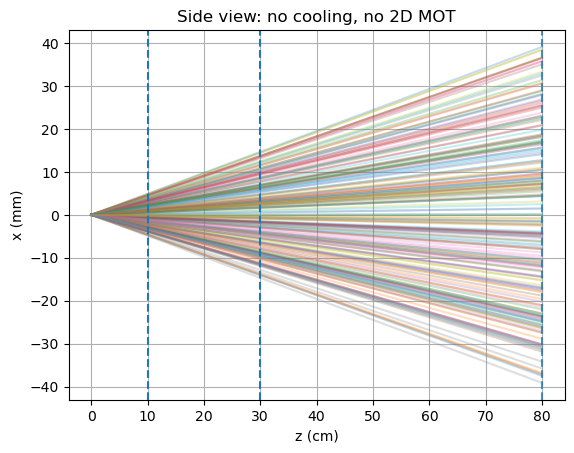

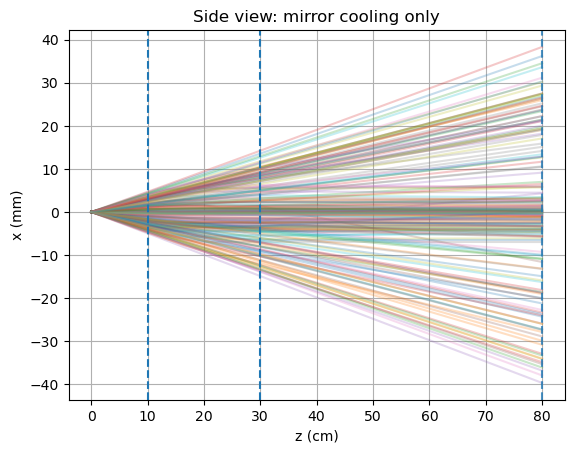

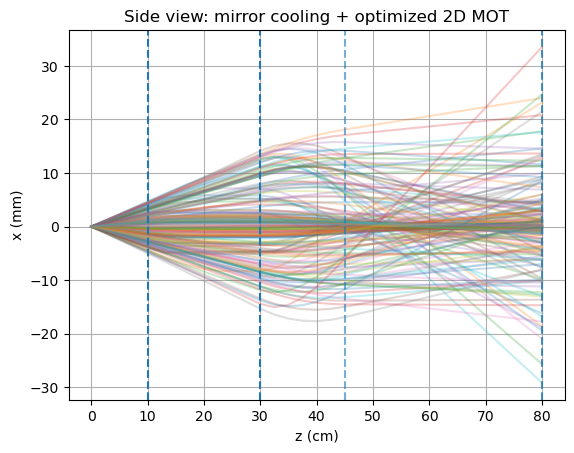

In [18]:
def plot_sideview(case, title, filename):
    traj = case["traj"]
    z_list = traj["z"]
    x_list = traj["x"]

    plt.figure()
    n = x_list[0].size
    for i in range(n):
        zz = np.array([z_list[j][i] for j in range(len(z_list))], dtype=float)
        xx = np.array([x_list[j][i] for j in range(len(x_list))], dtype=float)

        # Remove consecutive duplicate z-points at region boundaries
        keep = np.ones_like(zz, dtype=bool)
        keep[1:] = np.abs(np.diff(zz)) > 1e-12
        plt.plot(zz[keep]*1e2, xx[keep]*1e3, alpha=0.25)

    z_start = case["z_start"]*1e2
    z_end   = case["z_end"]*1e2
    z_mot_end = case["z_mot_end"]*1e2
    z_or = case["z_orifice"]*1e2

    plt.axvline(z_start, linestyle="--")
    plt.axvline(z_end, linestyle="--")
    if abs(z_mot_end - z_end) > 1e-12:
        plt.axvline(z_mot_end, linestyle="--", alpha=0.6)
    plt.axvline(z_or, linestyle="--", alpha=0.8)

    plt.xlabel("z (cm)")
    plt.ylabel("x (mm)")
    plt.title(title)
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    # plt.scatter(x, vx, s=1)
    plt.show()

plot_sideview(case1, "Side view: no cooling, no 2D MOT", "NoCooling")
plot_sideview(case2, "Side view: mirror cooling only", "TransverseCooling")
plot_sideview(case3, "Side view: mirror cooling + optimized 2D MOT", "2DMOT")


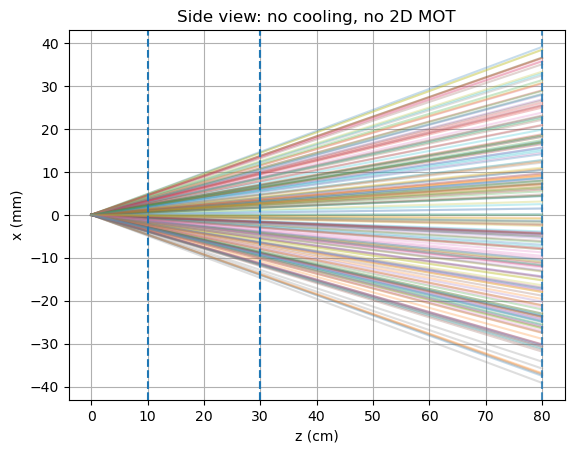

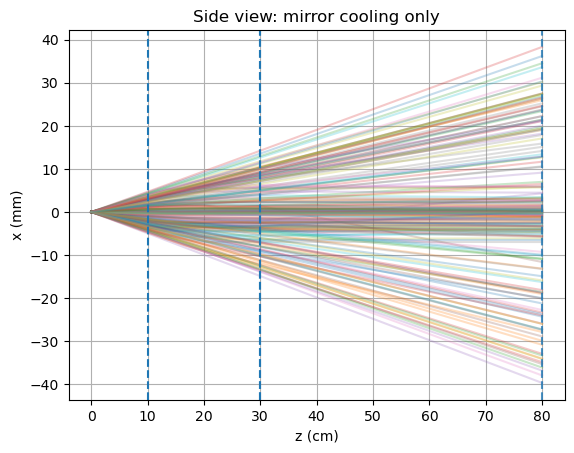

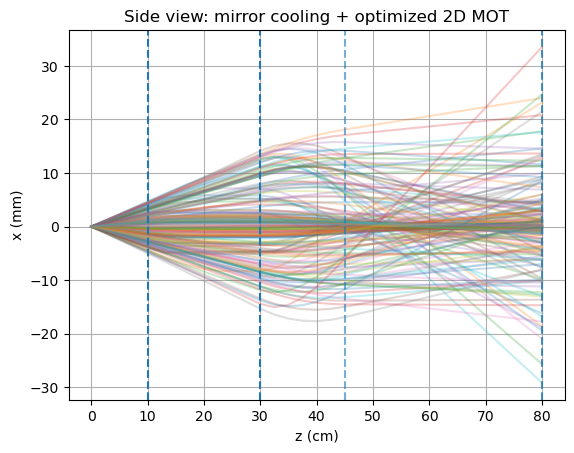

In [19]:
def plot_sideview(case, title, filename):
    traj = case["traj"]
    z_list = traj["z"]
    x_list = traj["x"]
    
    plt.figure()
    n = x_list[0].size
    for i in range(n):
        zz = [z_list[j][i] for j in range(len(z_list))]
        xx = [x_list[j][i] for j in range(len(x_list))]
        plt.plot(np.array(zz)*1e2, np.array(xx)*1e3, alpha=0.25)
    
    # region markers
    z_start = case["z_start"]*1e2
    z_end   = case["z_end"]*1e2
    z_mot_end = case["z_mot_end"]*1e2
    z_or = case["z_orifice"]*1e2
    
    plt.axvline(z_start, linestyle="--")
    plt.axvline(z_end, linestyle="--")
    plt.axvline(z_mot_end, linestyle="--", alpha=0.6)
    plt.axvline(z_or, linestyle="--", alpha=0.8)
    
    plt.xlabel("z (cm)")
    plt.ylabel("x (mm)")
    plt.title(title)
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_sideview(case1, "Side view: no cooling, no 2D MOT", "NoCooling")
plot_sideview(case2, "Side view: mirror cooling only", "TransverseCooling")
plot_sideview(case3, "Side view: mirror cooling + optimized 2D MOT", "2DMOT")



## Print optimized 2D MOT dimensions/parameters (requested)


In [1]:
# --- compute gains ---

gain_cooling = case2["Ndot_orifice"] / case1["Ndot_orifice"]
gain_bestmot = case3["Ndot_orifice"] / case2["Ndot_orifice"]
gain_total   = case3["Ndot_orifice"] / case1["Ndot_orifice"]

print("---- Achieved fluxes ----")
print(f"No cooling/no MOT flux      : {case1['Ndot_orifice']:.3e} atoms/s")
print(f"Cooling only flux           : {case2['Ndot_orifice']:.3e} atoms/s  (gain {gain_cooling:.3f}×)")
print(f"Cooling + best 2D MOT flux  : {case3['Ndot_orifice']:.3e} atoms/s  (gain vs cooling {gain_bestmot:.3f}×, total {gain_total:.3f}×)")
print("==== OPTIMIZED 2D MOT DESIGN (coarse scan) ====")
print(f"L_mot_cm  = {best['L_mot_cm']}")
print(f"beta_mot  = {best['beta']:.3e}  kg/s")
print(f"kappa_mot = {best['kappa']:.3e} N/m")
print("---- Achieved fluxes ----")
print(f"No cooling/no MOT flux      : {case1['Ndot_orifice']:.3e} atoms/s")
print(f"Cooling only flux           : {case2['Ndot_orifice']:.3e} atoms/s  (gain {gain_cooling:.3f}×)")
print(f"Cooling + best 2D MOT flux  : {case3['Ndot_orifice']:.3e} atoms/s  (gain vs cooling {gain_bestmot:.3f}×, total {gain_total:.3f}×)")


NameError: name 'case2' is not defined

# Improvements to be made:

* Use a more robust model for 2D MOT
* Implement machine learning to optimize